### Imports

In [1]:
%run ../LSTM/LSTM.ipynb

2025-07-26 20:31:24.003943: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-26 20:31:37.185713: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-26 20:31:37.193232: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-26 20:31:48.166202: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
janela_tempo = 12

### Categorização Geral (por tipo de tarefa e domínio)

| Tipo de Transfer Learning          | Tarefa Origem vs Alvo | Domínio Origem vs Alvo | Rótulos no Domínio Alvo | Exemplo típico                                          |
| ---------------------------------- | --------------------- | ---------------------- | ----------------------- | ------------------------------------------------------- |
| **Inductive Transfer Learning**    | ✅ Diferente           | ✅ Mesmo ou diferente   | ✅ Sim (supervisionado)  | Fine-tuning para nova tarefa                            |
| **Transductive Transfer Learning** | ❌ Mesma tarefa        | ✅ Diferente            | ❌ Não (não rotulado)    | Domain Adaptation                                       |
| **Unsupervised Transfer Learning** | ✅ Diferente           | ✅ Mesmo ou diferente   | ❌ Não (sem rótulos)     | Pré-treinar em dados grandes e transferir p/ clustering |


### Categorização por Mecanismo de Transferência

| Tipo técnico de TL   | O que transfere?                   | Exemplos                         |
| -------------------- | ---------------------------------- | -------------------------------- |
| **Parameter-based**  | Pesos e arquiteturas do modelo     | Fine-tuning, multitask           |
| **Instance-based**   | Dados reponderados ou selecionados | TrAdaBoost, importance weighting |
| **Feature-based**    | Representações (features latentes) | MMD, CORAL, Adversarial TL       |
| **Relational-based** | Estrutura relacional (grafos etc.) | GNNs, Knowledge Transfer in NLP  |


| Método/Categoria         | Tipo de Conhecimento Transferido        | Relacionado a                     | Exemplos / Técnicas Comuns                                      | Categoria Clássica   |
| ------------------------ | --------------------------------------- | --------------------------------- | --------------------------------------------------------------- | -------------------- |
| **Fine-tuning**          | Pesos (parâmetros da rede)              | Parameter-based, Network-based    | Descongelar camadas e ajustar pesos com learning rate menor     | **Parameter-based**  |
| **Feature extraction**   | Representações (features latentes)      | Feature-based, Mapping-based      | Usar camadas congeladas para extrair embeddings                 | **Feature-based**    |
| **Instance-based TL**    | Dados da tarefa origem (instâncias)     | Domain adaptation                 | Reponderação, seleção inteligente de amostras, TrAdaBoost       | **Instance-based**   |
| **Parameter-based TL**   | Parâmetros do modelo (pesos)            | Fine-tuning, Network-based        | Inicializar modelo alvo com pesos da tarefa origem              | **Parameter-based**  |
| **Feature-based TL**     | Espaços de representação                | Feature extraction, Mapping-based | Mapeamento via MMD, autoencoders, adversarial domain adaptation | **Feature-based**    |
| **Network-based TL**     | Arquitetura e pesos da rede             | Fine-tuning, Parameter-based      | Compartilhamento parcial de arquitetura, multitask learning     | **Parameter-based**  |
| **Mapping-based TL**     | Representações e domínios               | Feature-based                     | TCA, MMD, CORAL, Subspace Alignment                             | **Feature-based**    |
| **Adversarial-based TL** | Representações (invariância de domínio) | Feature-based                     | DANN (Domain-Adversarial NN), GANs para adaptação de domínio    | **Feature-based**    |
| **Relational-based TL**  | Relações entre entidades                | Knowledge graph, NLP              | Transferência em grafos ou modelos relacionais (ex: GNNs)       | **Relational-based** |


### Como tudo se conecta?

| Nível        | Categoria        | Exemplos ou Subtipos            |
| ------------ | ---------------- | ------------------------------- |
| **Geral**    | Inductive TL     | Fine-tuning, multitask learning |
|              | Transductive TL  | Domain adaptation, adversarial  |
|              | Unsupervised TL  | Feature extraction sem rótulos  |
| **Mecânico** | Parameter-based  | Fine-tuning                     |
|              | Instance-based   | TrAdaBoost, Reweighting         |
|              | Feature-based    | MMD, DANN, PCA, CORAL           |
|              | Relational-based | GNNs, NLP knowledge graphs      |


### Functions

In [45]:
def prepare_data(estacao, data_portion=1.0):
    anual_df = load_and_filter(estacao, 7, 18, True).set_index("data_hora")
    
    data_size = int(data_portion * (round(len(anual_df)/10)*10))

    anual_df = anual_df.iloc[0:data_size]

    train_size = int(0.7 * (round(len(anual_df)/10)*10))
    
    train_df = anual_df.iloc[0:train_size]
    test_df = anual_df.iloc[train_size:]

    train_input, train_output = data_to_input_and_output_lstm(train_df)
    test_input, test_output = data_to_input_and_output_lstm(test_df)
    
    return train_input, train_output, test_input, test_output, anual_df

def process_base_model(estacao):
    train_input, train_output, test_input, test_output, anual_df = prepare_data(estacao)

    model, _ = create_lstm_model(janela_tempo, "input_radiacao", True, False)
    train_model(model, train_input, train_output)

    get_results(model, train_input, test_input, test_output, anual_df)

    return model

def process_tl_approachs(base_model, estacao, with_fine_tuning):

    train_input, train_output, test_input, test_output, anual_df = prepare_data(estacao)
    
    base_model.trainable = False

    for layer in base_model.layers:
        layer.trainable = False
    
    lstm_layer_1 = base_model.get_layer("leo_lstm_1")
    lstm_layer_2 = base_model.get_layer("leo_lstm_2")

    # Criando novo modelo com a LSTM congelada + nova saída
    inputs = Input(shape=(janela_tempo, 1))
    x = lstm_layer_1(inputs)
    x = lstm_layer_2(x)
    x = Dense(32, activation='relu')(x)
    x = Dense(1, name="saida", activation='linear')(x)
    outputs = BatchNormalization()(x)

    transfer_model = Model(inputs=inputs, outputs=outputs)
    transfer_model.compile(optimizer=Adam(0.001), loss='mse')

    train_model(transfer_model, train_input, train_output)

    if with_fine_tuning:
        base_model.get_layer("leo_lstm_1").trainable = True
        base_model.get_layer("leo_lstm_2").trainable = True
        
        transfer_model.compile(optimizer=Adam(1e-5), loss='mse')
        
        train_model(transfer_model, train_input, train_output)

    get_results(transfer_model, train_input, test_input, test_output, anual_df)

def process_raw_compare(model, estacao, data_portion=1.0):
    train_input, train_output, test_input, test_output, anual_df = prepare_data(estacao, data_portion)

    get_results(model, train_input, test_input, test_output, anual_df)

    return model

def process_tl_approach_1(base_model, estacao):
    process_tl_approachs(base_model, estacao, False)

def process_tl_approach_2(base_model, estacao):
    process_tl_approachs(base_model, estacao, True)

def get_results(model, train_input, test_input, test_output, anual_df):
    train_pred = model.predict(train_input, verbose=0)
    test_pred = model.predict(test_input, verbose=0)

    print(get_metrics(test_pred, test_output))

    period = anual_df[train_pred.shape[0]:]['data'].iloc[:test_pred.shape[0]]
    plot_results_2(test_pred.reshape(test_pred.shape[0]), test_output, period)
        

# Base model

{'mse': 0.3032467716435374, 'rmse': 0.5506784648445383, 'mae': 0.43578713205341985, 'r2': 0.6158666974431338}


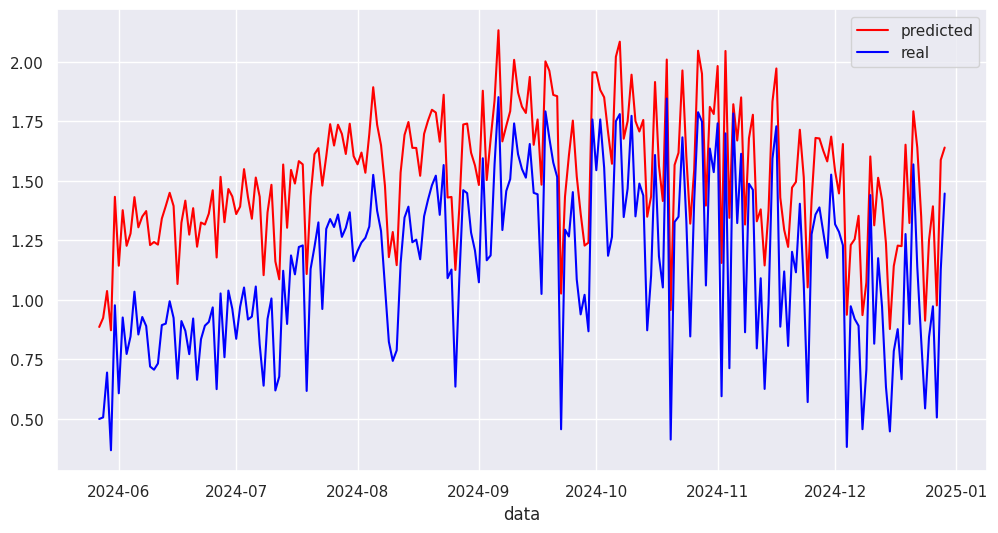

In [26]:
base_model = process_base_model("manaus")

# Transfer Learning

### Raw compare
- Full data
- Distant station

{'mse': 0.290245814195, 'rmse': 0.5387446651197578, 'mae': 0.448621406906332, 'r2': 0.5850042811006173}


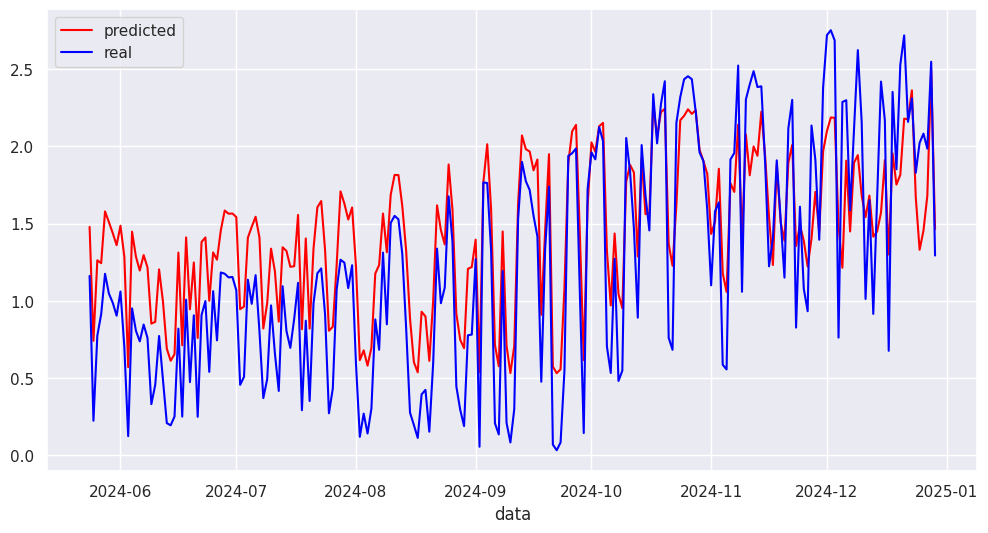

In [31]:
process_raw_compare(base_model, "pelotas")

- Near station
- Full data

{'mse': 0.17861810867634076, 'rmse': 0.42263235640014685, 'mae': 0.34046948169815655, 'r2': 0.7687881054604836}


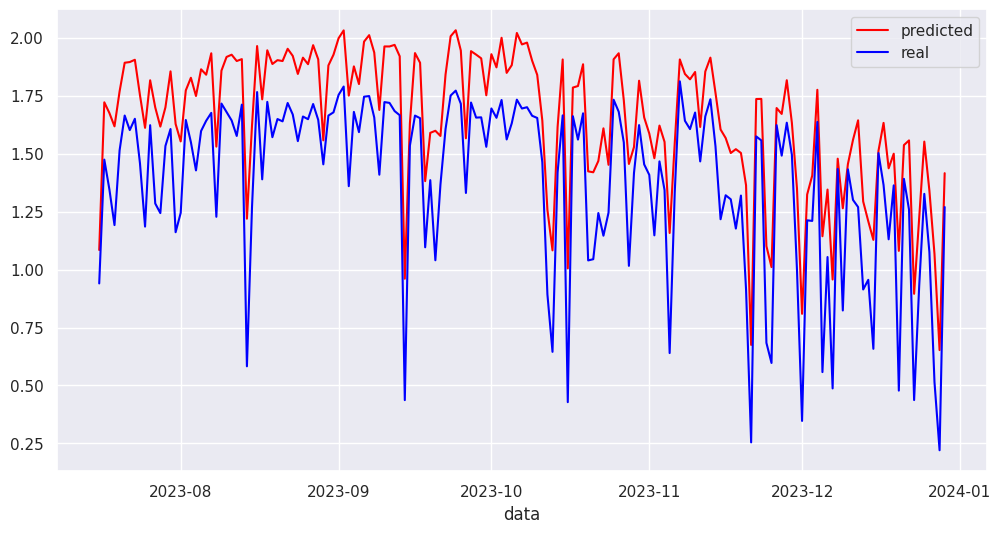

In [54]:
process_raw_compare(base_model, "itacoatiara")

### Approach 1: Feature Extraction
Freezing LSTM lasyers and trainig only new Dense
- Full data
- Distant station

{'mse': 0.16065965828226628, 'rmse': 0.4008237246998564, 'mae': 0.2878187398499902, 'r2': 0.8623069609040224}


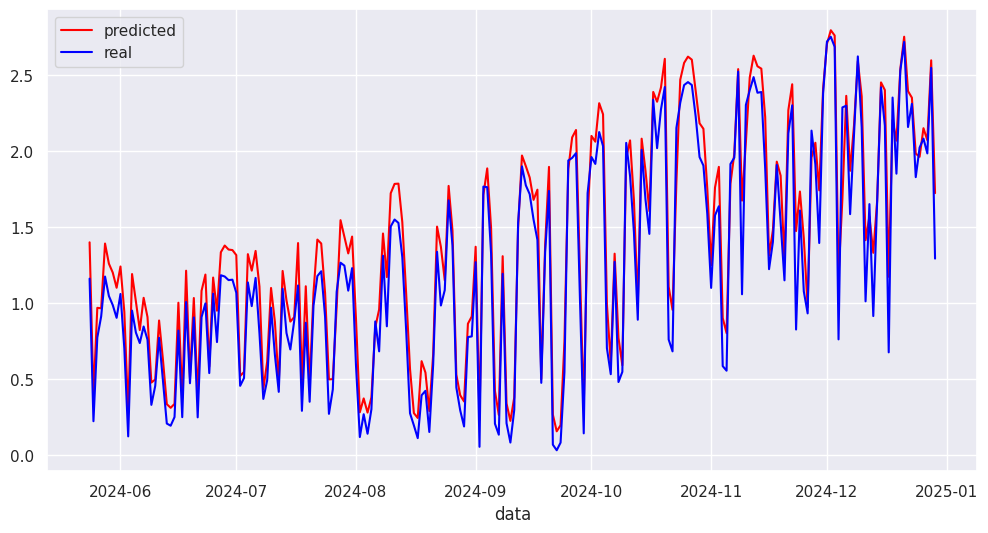

In [55]:
process_tl_approach_1(base_model, "pelotas")

- Full data
- Near station

{'mse': 0.2000445679366735, 'rmse': 0.4472634211923366, 'mae': 0.3491677045545007, 'r2': 0.7929070133253516}


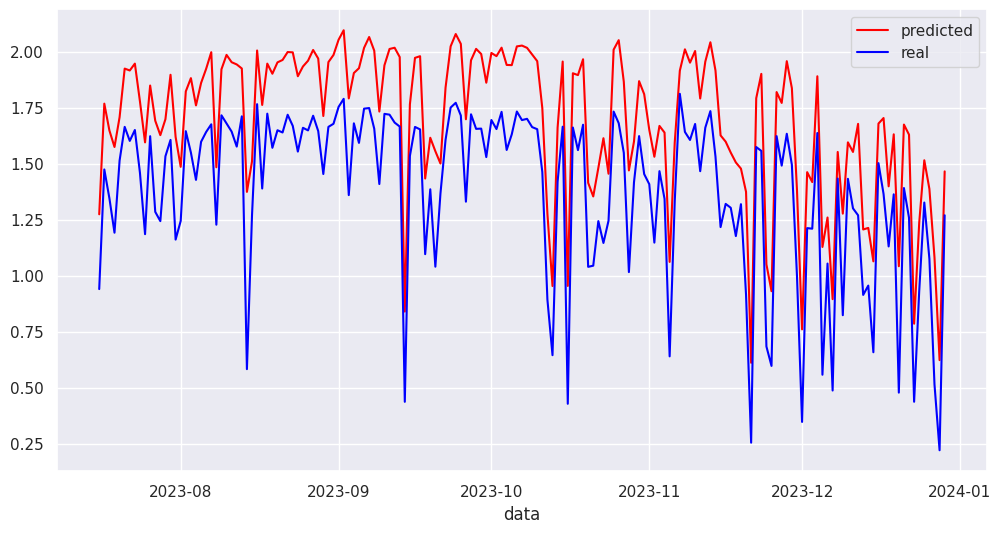

In [57]:
process_tl_approach_1(base_model, "itacoatiara")

### Approach 2: Fine Tuning
Freezing LSTM layers and trainig only new Dense, and then unfreeze LSTM layers and training in a sall learninig rate.
- Full data
- Distant station

{'mse': 0.11823743691436907, 'rmse': 0.3438567098580004, 'mae': 0.230636042202335, 'r2': 0.8832756297463142}


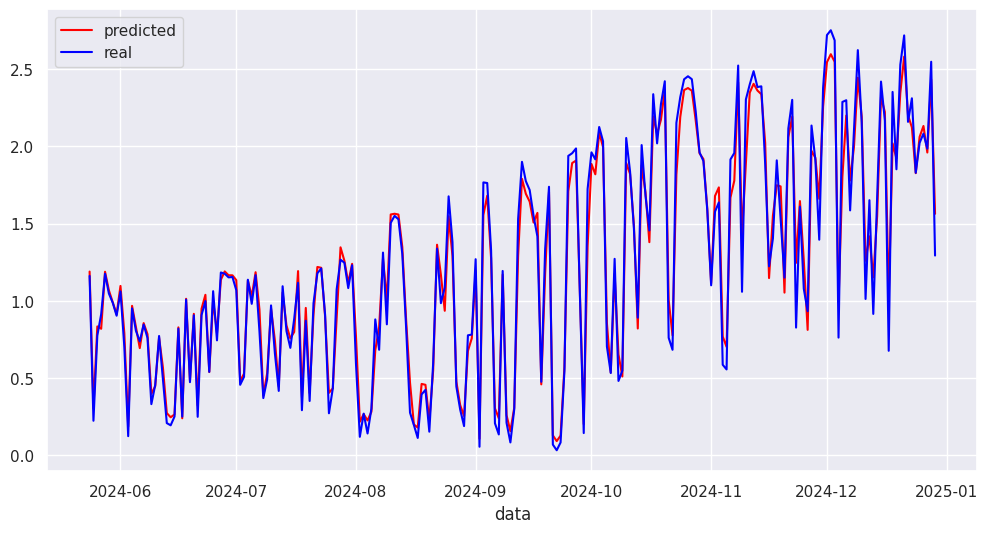

In [58]:
process_tl_approach_2(base_model, "pelotas")

- Full data
- Near station

{'mse': 0.0902556222295511, 'rmse': 0.30042573496548375, 'mae': 0.21082320343897892, 'r2': 0.8873820623916008}


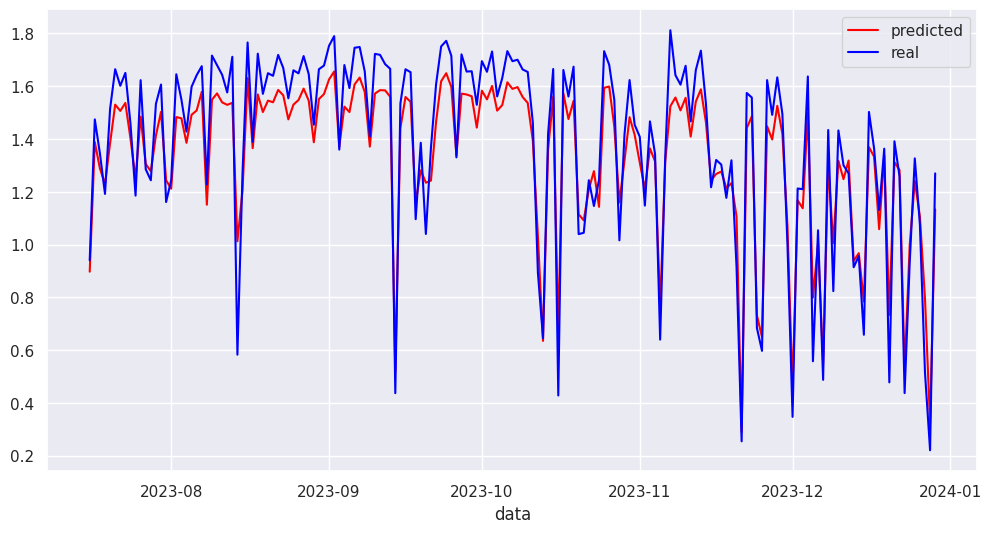

In [59]:
process_tl_approach_2(base_model, "itacoatiara")

In [11]:
# Feature Extraction (extração de características)
# → Congelar as camadas do modelo base e treinar apenas a nova "cabeça" (camadas finais).
# → Não há ajuste nos pesos pré-treinados.
# → Rápido e seguro, evita overfitting.
# Evidencias na literatura: 1

# Fine-tuning (ajuste fino) (incialização de pesos)
# → Primeiro congela a base, treina a cabeça (como acima).
# → Depois, descongela uma ou mais camadas do modelo base e treina com uma taxa de aprendizado menor.
# → Permite o modelo se adaptar melhor à nova tarefa.
# Evidencias na literatura: 3